In [23]:
# Cella — installazione
!pip install pulp

In [24]:
# Cella 2 — scarico i dati
import requests

url = "https://apidatos.ree.es/es/datos/mercados/precios-mercados-tiempo-real"
params = {
    "start_date": "2026-08-01T00:00",
    "end_date": "2026-08-29T23:59",
    "time_trunc": "hour"
}
risposta = requests.get(url, params=params)
dati = risposta.json()
print(dati)  # guarda com'è fatto, prima di andare oltre

{'data': {'type': 'Precios mercado peninsular en tiempo real', 'id': 'mer13', 'attributes': {'title': 'Precios mercado peninsular en tiempo real', 'last-update': '2026-08-28T20:46:36.000+02:00', 'description': None}, 'meta': {'cache-control': {'cache': 'MISS'}}}, 'included': [{'type': 'PVPC', 'id': '1001', 'groupId': None, 'attributes': {'title': 'PVPC', 'description': None, 'color': '#ffcf09', 'icon': None, 'type': None, 'magnitude': 'price', 'composite': False, 'last-update': '2026-08-28T20:46:36.000+02:00', 'values': [{'value': 201.18, 'percentage': 0.5300068496759576, 'datetime': '2026-08-01T00:00:00.000+02:00'}, {'value': 189.38, 'percentage': 0.5288614594096456, 'datetime': '2026-08-01T01:00:00.000+02:00'}, {'value': 182.24, 'percentage': 0.5309404498310221, 'datetime': '2026-08-01T02:00:00.000+02:00'}, {'value': 184.42, 'percentage': 0.5349849152935715, 'datetime': '2026-08-01T03:00:00.000+02:00'}, {'value': 196.61, 'percentage': 0.5328039890517873, 'datetime': '2026-08-01T04:00

In [25]:
import pandas as pd

# 'dati' è già in memoria dalla cella precedente — non richiamare di nuovo l'API

# selezioniamo per 'id', non per posizione nella lista: più robusto se REData
# in futuro cambia l'ordine in cui restituisce le serie
pvpc = next(item for item in dati['included'] if item['id'] == '1001')
valori = pvpc['attributes']['values']

df = pd.DataFrame(valori)
df = df[['datetime', 'value']].rename(columns={'value': 'prezzo_eur_mwh'})
df['datetime'] = pd.to_datetime(df['datetime'])

print(df.head())
print(f"Ore totali: {len(df)} — minimo: {df['prezzo_eur_mwh'].min()} — massimo: {df['prezzo_eur_mwh'].max()}")

                   datetime  prezzo_eur_mwh
0 2026-08-01 00:00:00+02:00          201.18
1 2026-08-01 01:00:00+02:00          189.38
2 2026-08-01 02:00:00+02:00          182.24
3 2026-08-01 03:00:00+02:00          184.42
4 2026-08-01 04:00:00+02:00          196.61
Ore totali: 696 — minimo: 3.27 — massimo: 391.03


In [26]:
# Cella — modello di ottimizzazione
import pulp

prezzi = df['prezzo_eur_mwh'].tolist()
ore = range(len(prezzi))

potenza_mw = 1
capacita_mwh = 2
efficienza = 0.9  # andata e ritorno

problema = pulp.LpProblem("arbitraggio_batteria", pulp.LpMaximize)

carica = pulp.LpVariable.dicts("carica", ore, lowBound=0, upBound=potenza_mw)
scarica = pulp.LpVariable.dicts("scarica", ore, lowBound=0, upBound=potenza_mw)
soc = pulp.LpVariable.dicts("soc", ore, lowBound=0, upBound=capacita_mwh)

# obiettivo: massimizza il profitto (ricavo dallo scaricare meno costo del caricare)
problema += pulp.lpSum([scarica[t] * prezzi[t] - carica[t] * prezzi[t] for t in ore])

# vincolo: il livello di carica di ogni ora dipende da quella precedente
for t in ore:
    livello_precedente = soc[t - 1] if t > 0 else capacita_mwh / 2  # si parte a metà carica
    problema += soc[t] == livello_precedente + carica[t] * (efficienza ** 0.5) - scarica[t] / (efficienza ** 0.5)

problema.solve()

profitto = pulp.value(problema.objective)
print("Stato:", pulp.LpStatus[problema.status])
print("Profitto stimato sul periodo:", round(profitto, 2), "€")

Stato: Optimal
Profitto stimato sul periodo: 15183.61 €


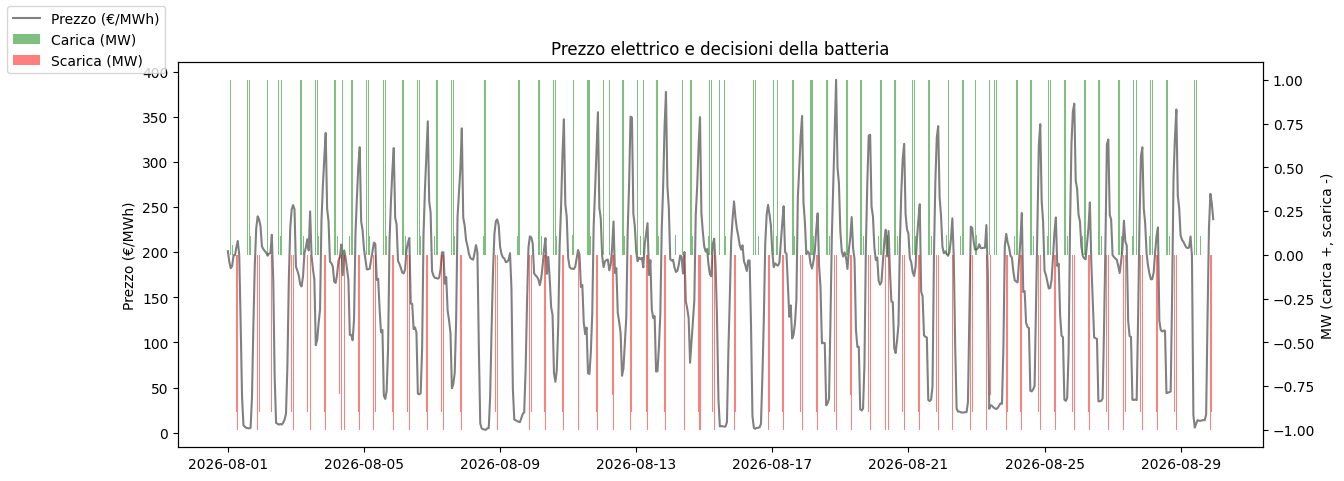

In [27]:
import matplotlib.pyplot as plt

valori_carica = [carica[t].value() for t in ore]
valori_scarica = [scarica[t].value() for t in ore]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df['datetime'], df['prezzo_eur_mwh'], color='gray', label='Prezzo (€/MWh)')
ax1.set_ylabel('Prezzo (€/MWh)')

ax2 = ax1.twinx()
ax2.bar(df['datetime'], valori_carica, color='green', alpha=0.5, width=0.03, label='Carica (MW)')
ax2.bar(df['datetime'], [-v for v in valori_scarica], color='red', alpha=0.5, width=0.03, label='Scarica (MW)')
ax2.set_ylabel('MW (carica +, scarica -)')

fig.legend(loc='upper left')
plt.title('Prezzo elettrico e decisioni della batteria')
plt.show()

In [28]:
soglia = 0.01  # MW — sotto questa soglia consideriamo il movimento trascurabile
ore_totali = len(list(ore))
ore_carica = sum(1 for t in ore if carica[t].value() > soglia)
ore_scarica = sum(1 for t in ore if scarica[t].value() > soglia)

print(f"Ore in cui carica: {ore_carica} su {ore_totali}")
print(f"Ore in cui scarica: {ore_scarica} su {ore_totali}")

Ore in cui carica: 155 su 696
Ore in cui scarica: 105 su 696


In [29]:
costo_degrado = 5  # €/MWh movimentato — segnaposto, da sostituire con una fonte reale più avanti

problema2 = pulp.LpProblem("arbitraggio_con_degrado", pulp.LpMaximize)
carica2 = pulp.LpVariable.dicts("carica2", ore, lowBound=0, upBound=potenza_mw)
scarica2 = pulp.LpVariable.dicts("scarica2", ore, lowBound=0, upBound=potenza_mw)
soc2 = pulp.LpVariable.dicts("soc2", ore, lowBound=0, upBound=capacita_mwh)

problema2 += pulp.lpSum([
    scarica2[t] * prezzi[t] - carica2[t] * prezzi[t] - costo_degrado * (carica2[t] + scarica2[t])
    for t in ore
])

for t in ore:
    livello_precedente = soc2[t - 1] if t > 0 else capacita_mwh / 2
    problema2 += soc2[t] == livello_precedente + carica2[t] * (efficienza ** 0.5) - scarica2[t] / (efficienza ** 0.5)

problema2.solve()

ore_carica2 = sum(1 for t in ore if carica2[t].value() > soglia)
ore_scarica2 = sum(1 for t in ore if scarica2[t].value() > soglia)

print("Profitto netto (con degrado):", round(pulp.value(problema2.objective), 2), "€")
print(f"Ore carica: {ore_carica2} su {ore_totali} (prima: {ore_carica})")
print(f"Ore scarica: {ore_scarica2} su {ore_totali} (prima: {ore_scarica})")

Profitto netto (con degrado): 14223.25 €
Ore carica: 132 su 696 (prima: 155)
Ore scarica: 90 su 696 (prima: 105)


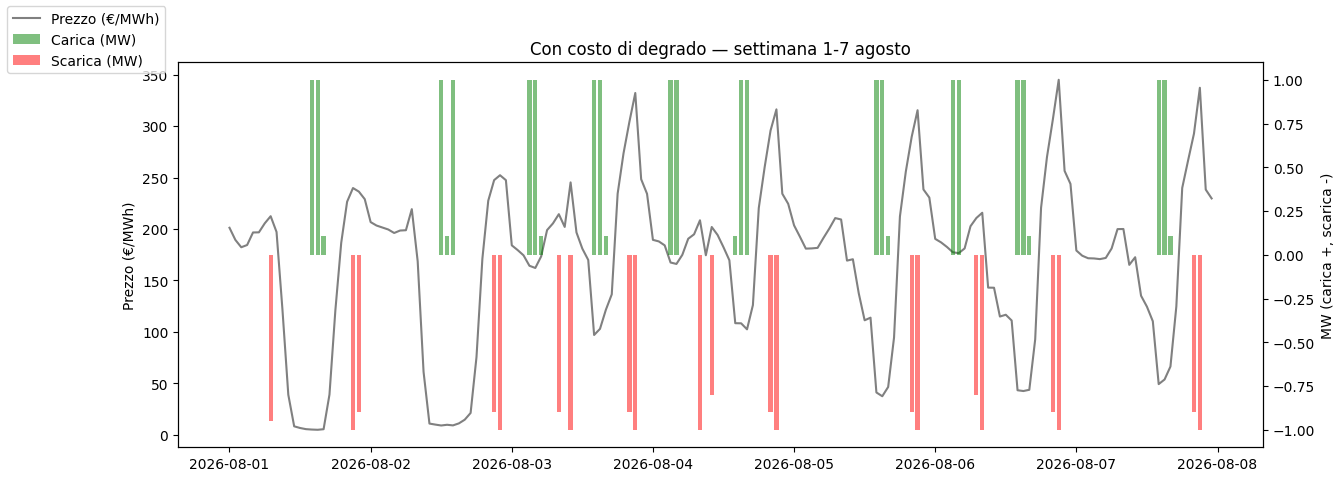

In [30]:
df_settimana = df[(df['datetime'] >= '2026-08-01') & (df['datetime'] < '2026-08-08')].copy()
indici_settimana = df_settimana.index

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(df_settimana['datetime'], df_settimana['prezzo_eur_mwh'], color='gray', label='Prezzo (€/MWh)')
ax1.set_ylabel('Prezzo (€/MWh)')

ax2 = ax1.twinx()
valori_carica2 = [carica2[t].value() for t in indici_settimana]
valori_scarica2 = [scarica2[t].value() for t in indici_settimana]
ax2.bar(df_settimana['datetime'], valori_carica2, color='green', alpha=0.5, width=0.03, label='Carica (MW)')
ax2.bar(df_settimana['datetime'], [-v for v in valori_scarica2], color='red', alpha=0.5, width=0.03, label='Scarica (MW)')
ax2.set_ylabel('MW (carica +, scarica -)')

fig.legend(loc='upper left')
plt.title('Con costo di degrado — settimana 1-7 agosto')
plt.show()

In [31]:
print("Profitto senza degrado (mese):", round(pulp.value(problema.objective), 2), "€")

Profitto senza degrado (mese): 15183.61 €
